In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import readsav

import tol_colors
from scipy.interpolate import interp1d
from scipy.signal import convolve

import astropy.units as u
from astropy.coordinates import SpectralCoord
import astropy

In [180]:

#conversions between wavelength and doppler shift
def veltrans(x):
    return ((((x+lamb0)/lamb0)-1)*c)/mu

def veltrans2(x):
    return ((((x+lamb0)/lamb0)-1)*c)/mu2

def wltrans(x):
    return ((((x/c)+1)*lamb0)-lamb0)

#Don't worry about this -- only useful if you need to make comp to observations
def gaussian_psf(x, fwhm):
	#x = wavelength [nm]
	# fwhm in [nm]
    sigma = fwhm / (2 * np.sqrt(2 * np.log(2)))  # Calculate sigma from FWHM
    tr = np.exp(-(x)**2 / (2 * (sigma**2)))
    tr /= tr.sum()
    return tr

def doppler_to_wavelength(vel, rest_wave=396.847, speed_of_light=299792458):
    # convert between velocity/Doppler shift and wavelength shift
    # vel is given in km/s after the RADYN conversion from "typical doppler units" 
    # (so we have to x1000 to convert with c given in m/s
    # speed of light in m/s
    # rest wavelength in whatever units you want the wavelength shift to be
    
    delwave = -rest_wave*vel*1000/speed_of_light
    return delwave #add central wavelength to the output to get absolute wavelength

In [122]:
# before this, will need to save variables tg1t, z1t, ne1t, pg1t, q, nq, qnorm, outintt, nmu to save file... or access some other way
filename = '/Users/coletamburri/Desktop/RADYN_Run_4Madie/run_NTE_3F10_19_5.sav'


# transition of choice... Ca II H as an example
kr=16 #Ca II H - 20 is Ca II 8542 - see Mats Carlsson analysis_tools.pdf

c=2.99e5
mu=1


In [85]:
read = readsav(filename)

In [86]:
q_new = read['q'] #frequency variable, in units of "typical Doppler velocity"
nq_new = read['nq']
qnorm_new= read['qnorm'] # typical doppler velocity in units of km/s
outintt_new = read['outintt'] #stores all line intensities
nmu_new = 5
ne1t = read['ne1t'] #electron density with height
tg1t = read['tg1t'] #temperature stratification
z1t = read['z1t'] # height stratification, z space
timet = read['timet'] #times in the simulation.  Delta between steps are not the same! so use this array to see where (when) you are... 

In [18]:
np.shape(read['tg1t'])

(518, 191)

In [24]:
timet

array([0.00000000e+00, 2.75225230e-05, 1.86138971e-02, 3.14868996e-02,
       6.79700259e-02, 1.00000000e-01, 2.00000000e-01, 3.00000000e-01,
       3.39787597e-01, 4.00000000e-01, 5.00000000e-01, 6.00000000e-01,
       7.00000000e-01, 8.00000000e-01, 8.40622661e-01, 9.00000000e-01,
       1.00000000e+00, 1.10000000e+00, 1.14297076e+00, 1.20000000e+00,
       1.30000000e+00, 1.40000000e+00, 1.44140540e+00, 1.50000000e+00,
       1.60000000e+00, 1.70000000e+00, 1.80000000e+00, 1.90000000e+00,
       2.00000000e+00, 2.10000000e+00, 2.20000000e+00, 2.30000000e+00,
       2.40000000e+00, 2.50000000e+00, 2.60000000e+00, 2.70000000e+00,
       2.80000000e+00, 2.90000000e+00, 2.98053292e+00, 3.00000000e+00,
       3.10000000e+00, 3.20000000e+00, 3.30000000e+00, 3.40000000e+00,
       3.50000000e+00, 3.60000000e+00, 3.70000000e+00, 3.80000000e+00,
       3.90000000e+00, 4.00000000e+00, 4.10000000e+00, 4.19034040e+00,
       4.20000000e+00, 4.30000000e+00, 4.40000000e+00, 4.50000000e+00,
      

In [19]:
#choose times to choose, in seconds
times_choice = np.arange(0,50,1)
times_choice

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49])

In [22]:
# find indices in timet corresponding to these times
timeinds = []
timevals = []
for i in range(len(times_choice)):
    nearestindex, nearestvalue = min(enumerate(timet), key=lambda x: abs(x[1] - times_choice[i]))
    timeinds.append(nearestindex)
    timevals.append(nearestvalue)

    

In [32]:
cmap_choic

50

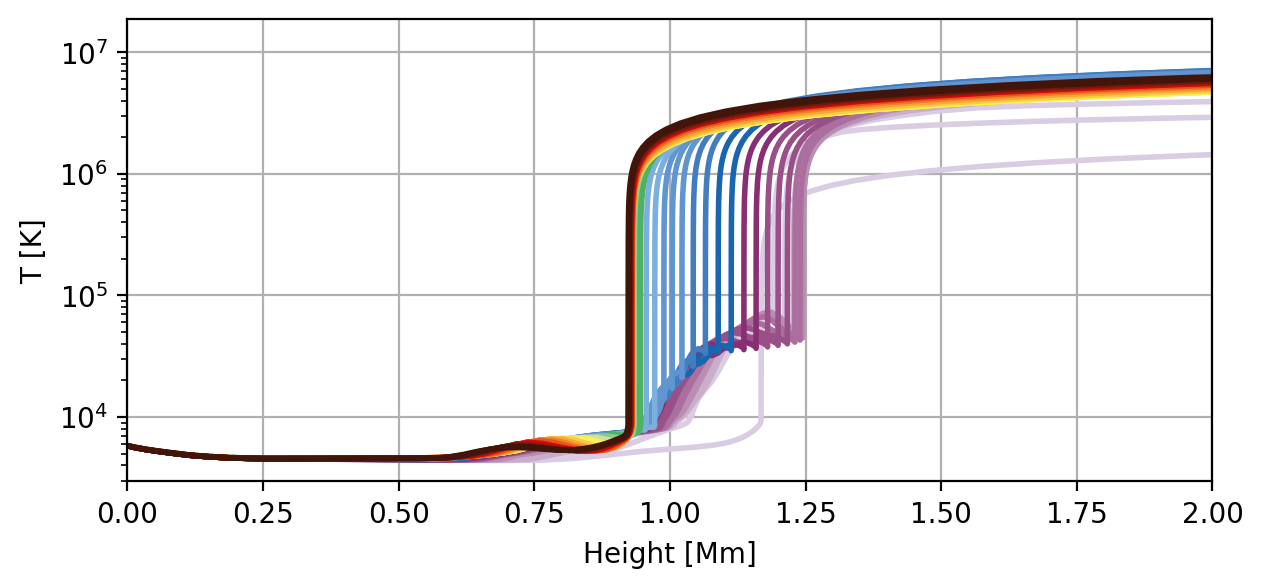

In [35]:
# temperature plot
#for the next three, I just plot every 1s, which means querying timet to find out what index that is

ncol2 = len(timevals)
map = tol_colors.tol_cmap(colormap='rainbow_discrete',lut=ncol2)
cmap_choice2 = map(np.linspace(0,1,ncol2))

#cmap_choice2 = ['#332288','#88CCEE','#44AA99','#117733','#999933','#CC6677','#AA4499','#AA4499','#AA4499','#AA4499']

fig,ax=plt.subplots(dpi=200,figsize=(7,3))
for i in range(len(timeinds)):
    ax.plot(read['z1t'][int(timeinds[i]),:]/1e8,(read['tg1t'][int(timeinds[i]),:]),label='t = '+str(round(timevals[i],2))+'s',linewidth=2,c=cmap_choice2[i])

#for i in range(len(times2)):
#    ax.plot(read['z1t'][int(times2[i]),:]/1e8,(read['tg1t'][int(times2[i]),:]),color=cmap_choice2[len(timesinit)+i],label='t = '+str(round(times2[i]/10,2))+'s',linewidth=2)

ax.grid()
#ax.legend(fontsize=8)
ax.set_ylabel('T [K]')
ax.set_xlabel('Height [Mm]')
ax.set_xlim([0,2])
plt.yscale('log')

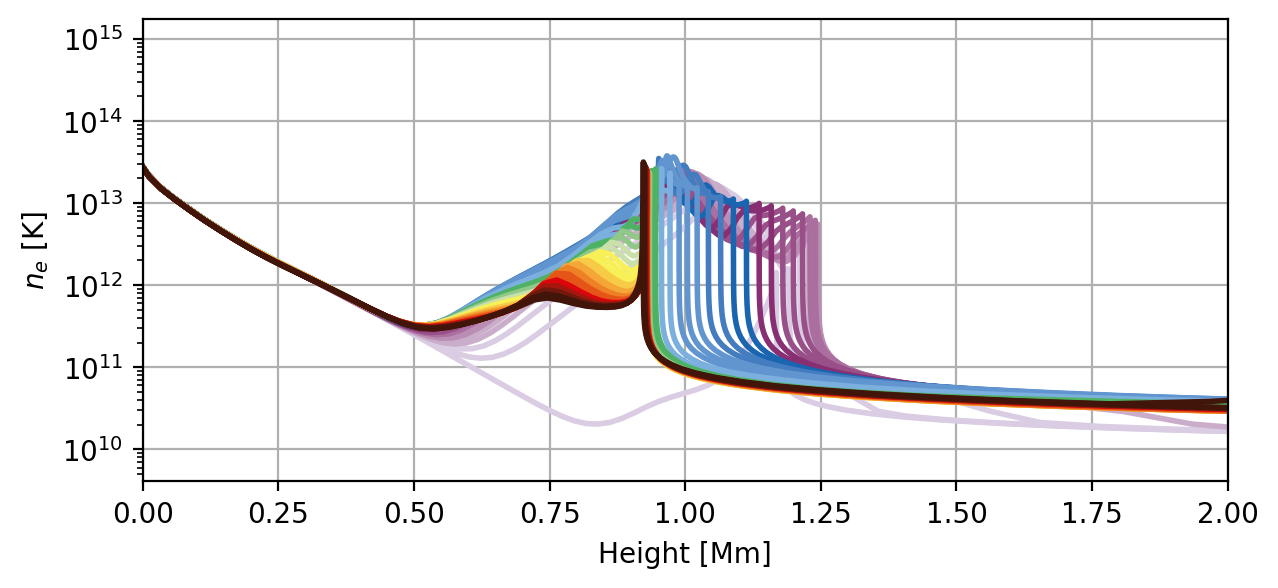

In [38]:
# electron number density

fig,ax=plt.subplots(dpi=200,figsize=(7,3))
for i in range(len(timevals)):
    ax.plot(read['z1t'][int(timeinds[i]),:]/1e8,(read['ne1t'][int(timeinds[i]),:]),color=cmap_choice2[i],label='t = '+str(round(timevals[i]/10,2))+'s',linewidth=2)

#for i in range(len(times2)):
#    ax.plot(read['z1t'][int(times2[i]),:]/1e8,(read['ne1t'][int(times2[i]),:]),color=cmap_choice2[len(timesinit)+i],label='t = '+str(round(times2[i]/10,2))+'s',linewidth=2)

ax.grid()
#ax.legend(fontsize=8)
ax.set_ylabel(r'$n_e$ [K]')
ax.set_xlabel('Height [Mm]')
ax.set_xlim([0,2])
plt.yscale('log')

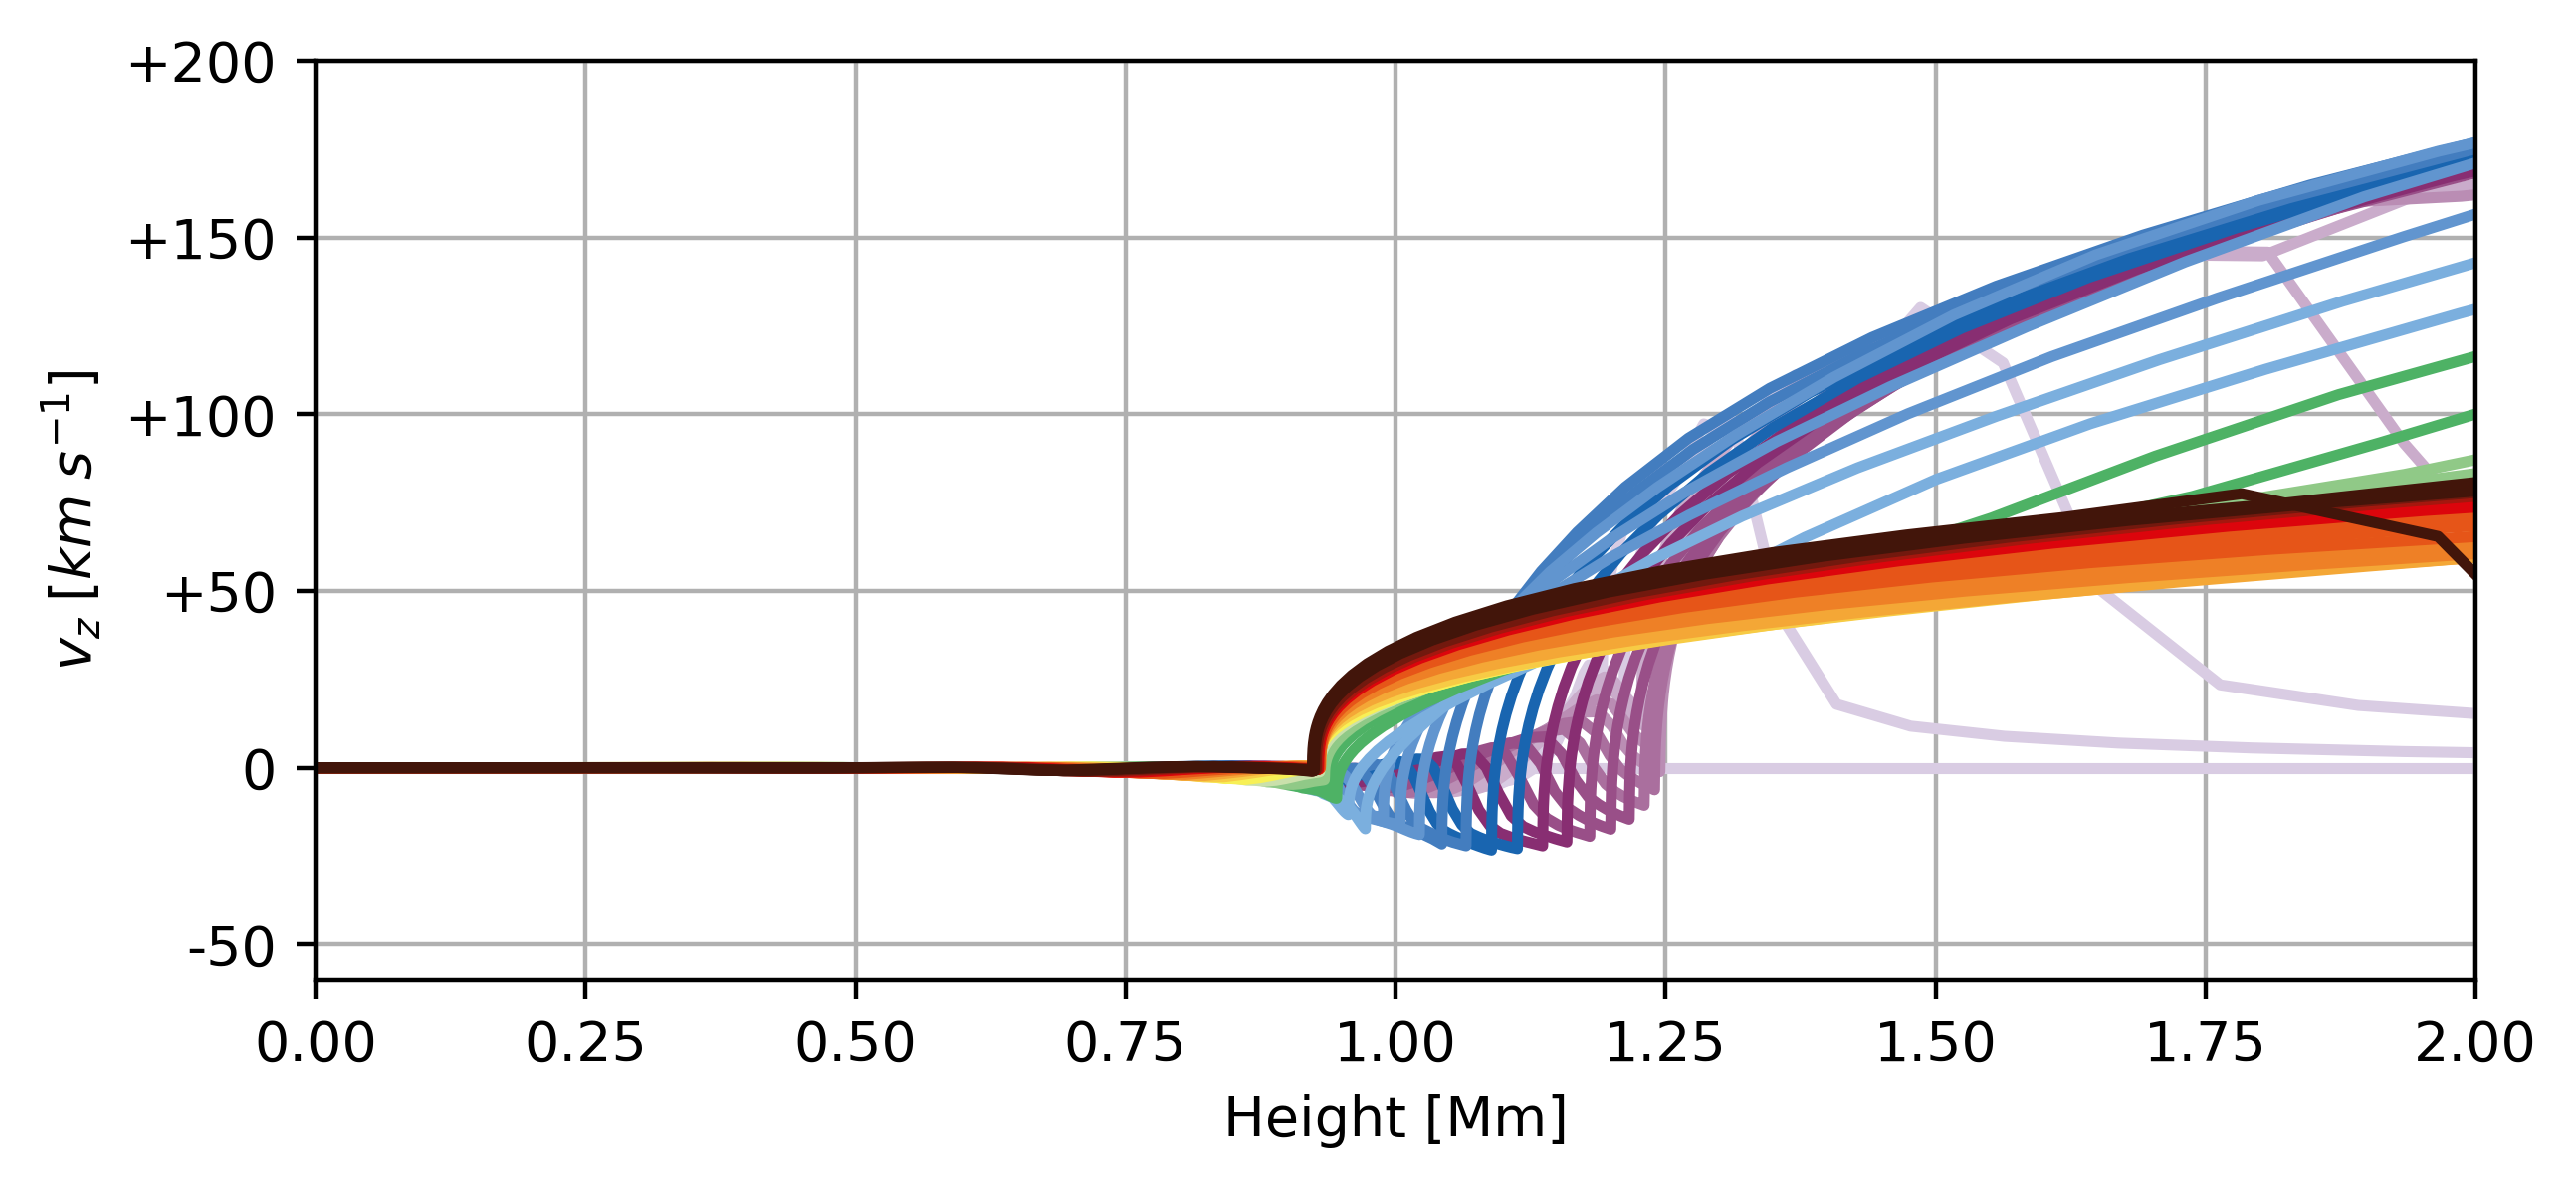

In [40]:
#velocity
fig,ax=plt.subplots(dpi=400,figsize=(7,3))
for i in range(len(timevals)):
    ax.plot(read['z1t'][int(timeinds[i]),:]/1e8,(read['vz1t'][int(timeinds[i]),:])/1e5,color=cmap_choice2[i],label='t = '+str(round(timevals[i]/10,2))+'s',linewidth=2)

#for i in range(len(times2)):
#    ax.plot(read['z1t'][int(times2[i]),:]/1e8,(read['ne1t'][int(times2[i]),:]),color=cmap_choice2[len(timesinit)+i],label='t = '+str(round(times2[i]/10,2))+'s',linewidth=2)

ax.grid()
#ax.legend(fontsize=8,loc='lower left')
ax.set_ylabel(r'$v_z\; [km\;s^{-1}]$')
ax.set_xlabel('Height [Mm]')
ax.set_xlim([0,2])
ax.set_ylim([-60,200])
ax.set_yticks([-50,0,50,100,150,200],labels=['-50','0','+50','+100','+150','+200'])
#plt.yscale('log')

In [164]:
muind=4 #this means the 4th mu-angle; mu=0.95 is 4, looking ~directly from above
caii_h = outintt_new[:,16,muind,1:nq_new[16]]
halpha = outintt_new[:,3,muind,1:nq_new[3]]
hbeta = outintt_new[:,4,muind,1:nq_new[4]]

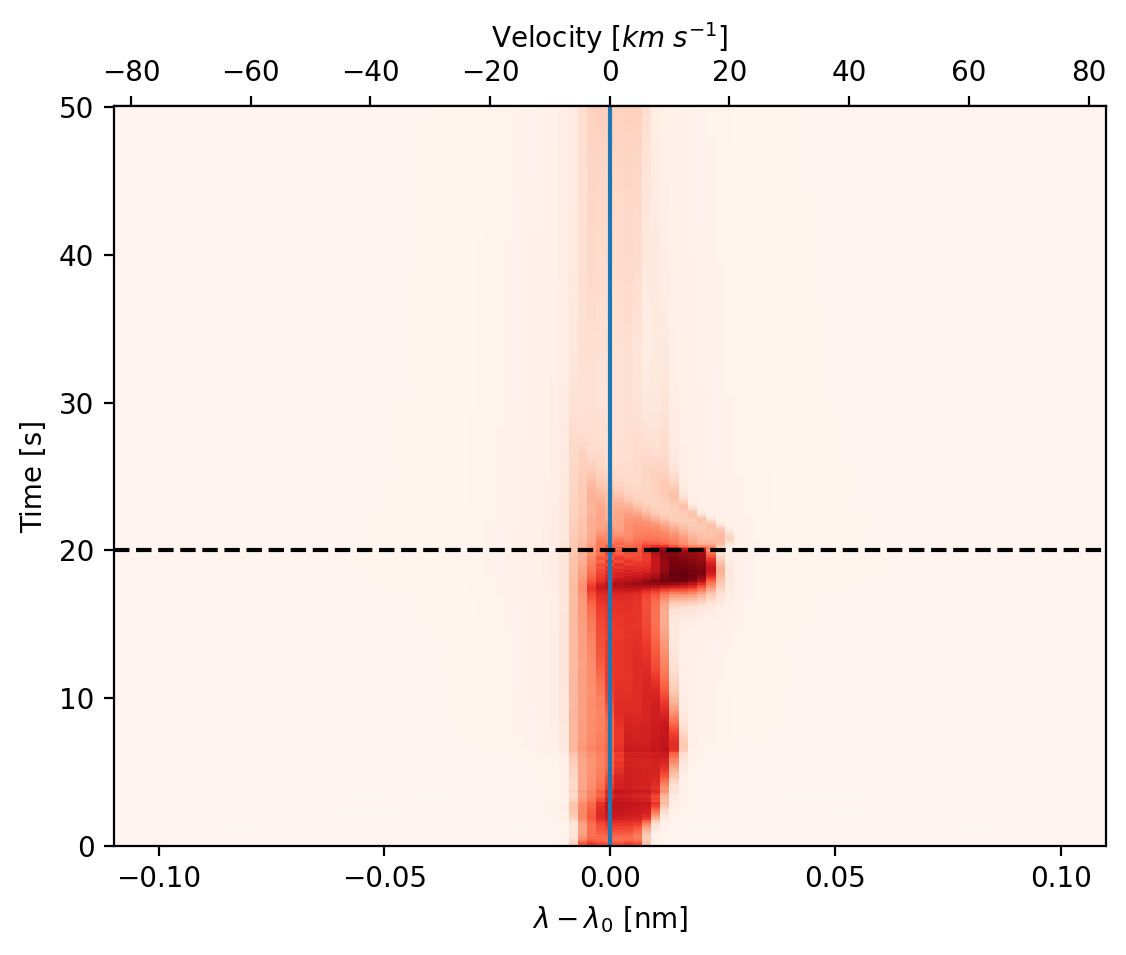

In [177]:
# throughout, vertical line is line center, horizontal line is when we turn heating off in the simulation.

# Ca II H ...
kr=16
line=396.847
lamb0=line

freq = q_new[kr,0:nq_new[kr]-1]*qnorm_new
x = (doppler_to_wavelength((q_new[kr,0:nq_new[kr]-1]*qnorm_new),rest_wave=line))

fig,ax=plt.subplots(dpi=200)
ax.pcolormesh(x,timet,caii_h,cmap='Reds')
ax.set_xlim([-.11,.11])
ax.axvline(0)
ax.set_xticks([-0.1,-0.05,0,0.05,0.1])
secaxx = ax.secondary_xaxis('top', functions=(veltrans,wltrans))
secaxx.set_xlabel(r'Velocity $[km\; s^{-1}]$',fontsize=10)
ax.set_xlabel(r'$\lambda-\lambda_0$ [nm]')
ax.set_ylabel('Time [s]')
ax.axhline(20,linestyle='--',color='black')

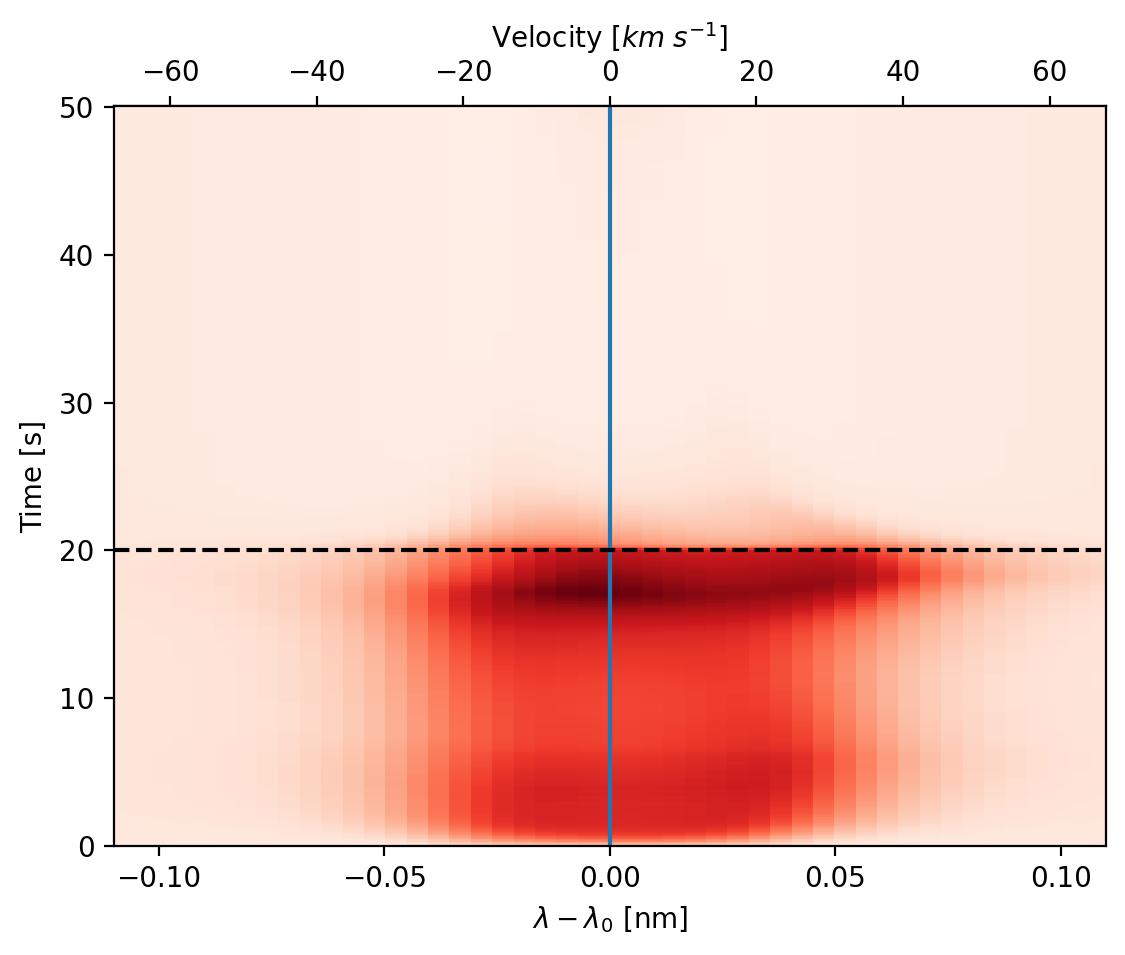

In [178]:
#... h-beta ...
kr=4
line=486.1375
lamb0=line

freq = q_new[kr,0:nq_new[kr]-1]*qnorm_new
x = (doppler_to_wavelength((q_new[kr,0:nq_new[kr]-1]*qnorm_new),rest_wave=line))


fig,ax=plt.subplots(dpi=200)
ax.pcolormesh(x,timet,hbeta,cmap='Reds')
ax.set_xlim([-.11,.11])
ax.axvline(0)
ax.set_xticks([-0.1,-0.05,0,0.05,0.1])
secaxx = ax.secondary_xaxis('top', functions=(veltrans,wltrans))
secaxx.set_xlabel(r'Velocity $[km\; s^{-1}]$',fontsize=10)
ax.set_xlabel(r'$\lambda-\lambda_0$ [nm]')
ax.set_ylabel('Time [s]')
ax.axhline(20,linestyle='--',color='black')

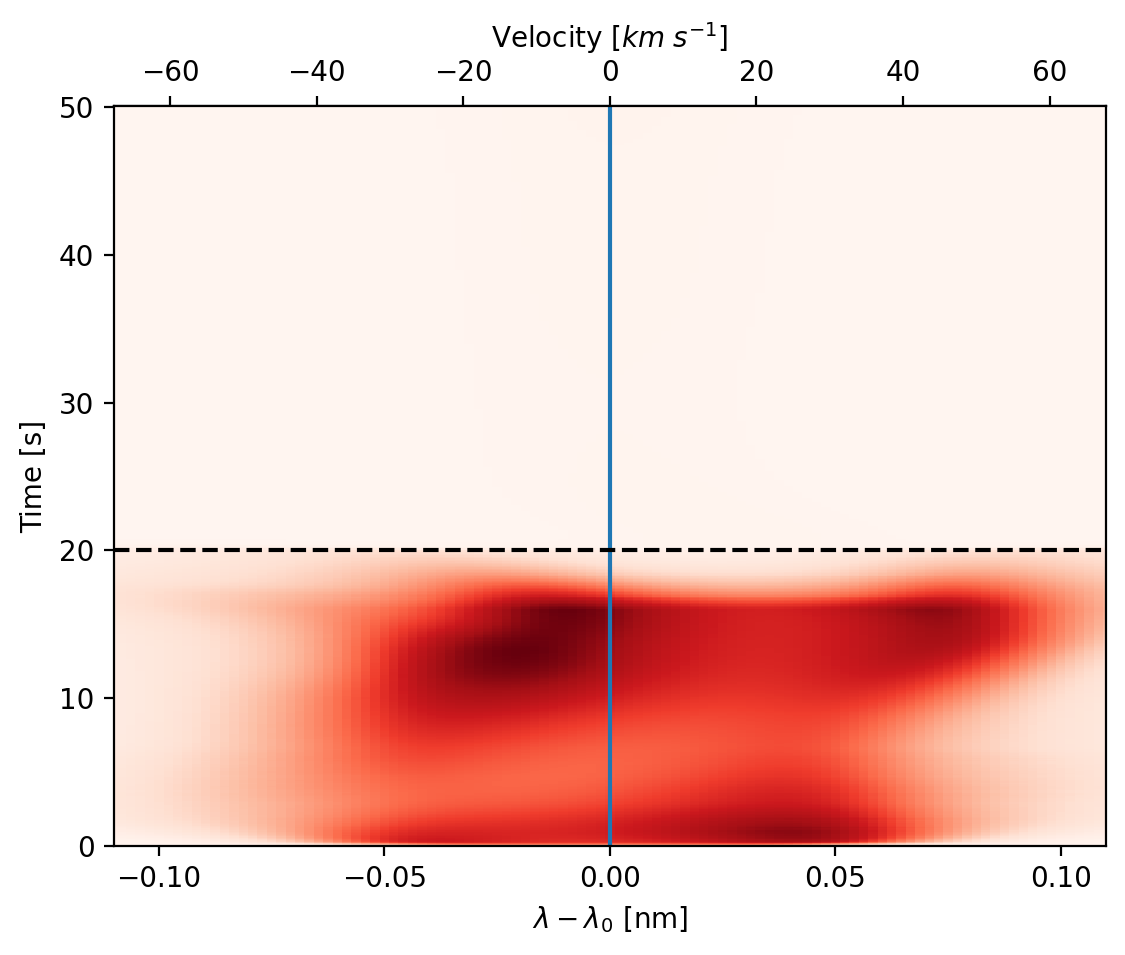

In [179]:
# ... and h-alpha
kr=3
line=486.1375
lamb0=line

freq = q_new[kr,0:nq_new[kr]-1]*qnorm_new
x = (doppler_to_wavelength((q_new[kr,0:nq_new[kr]-1]*qnorm_new),rest_wave=line))


fig,ax=plt.subplots(dpi=200)
ax.pcolormesh(x,timet,halpha,cmap='Reds')
ax.set_xlim([-.11,.11])
ax.axvline(0)
ax.set_xticks([-0.1,-0.05,0,0.05,0.1])
secaxx = ax.secondary_xaxis('top', functions=(veltrans,wltrans))
secaxx.set_xlabel(r'Velocity $[km\; s^{-1}]$',fontsize=10)
ax.set_xlabel(r'$\lambda-\lambda_0$ [nm]')
ax.set_ylabel('Time [s]')
ax.axhline(20,linestyle='--',color='black')